# Roughness LUT Diagnostic Analysis

This notebook investigates the systematic latitude correlation in roughness correction factors.

**Current Issue:** Factors show r ≈ -0.98 correlation with latitude (should be random, |r| < 0.3)

**Goals:**
1. Visualize correction factors across parameter space
2. Examine actual thermal simulations used to generate LUT
3. Understand temperature distributions and thermal self-heating
4. Identify root cause of systematic bias

**Key Insight:** Even at high latitudes with grazing illumination, crater rims should heat up and radiate. The energy integrated over a full rotation should equal that of a flat surface at the same latitude, with normalization accounting only for discretization errors.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
from scipy.stats import pearsonr
from datetime import datetime

# Setup paths
current_dir = Path(os.getcwd()).resolve()
if current_dir.name == 'TEMPEST_RAD':
    root_dir = current_dir.parent
else:
    root_dir = current_dir

os.chdir(root_dir)
sys.path.append(str(root_dir))

from TEMPEST_RAD.simulator import RoughnessLUT, planck_function
from src.utilities.config import Config

print(f"Working directory: {os.getcwd()}")
print(f"Root directory: {root_dir}")

Working directory: /Users/duncan/Desktop/DPhil/TEMPEST
Root directory: /Users/duncan/Desktop/DPhil/TEMPEST


## 1. Load and Inspect LUT Structure

In [2]:
# Load the test LUT
LUT_FILE = root_dir / "roughness_lut_moon_test.h5"

print("=" * 80)
print("LUT FILE INFORMATION")
print("=" * 80)

lut_timestamp = os.path.getmtime(LUT_FILE)
print(f"\nFile: {LUT_FILE.name}")
print(f"Modified: {datetime.fromtimestamp(lut_timestamp).strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Size: {LUT_FILE.stat().st_size / 1024 / 1024:.2f} MB")

with h5py.File(LUT_FILE, 'r') as f:
    print(f"\nDatasets:")
    for key in f.keys():
        shape = f[key].shape if hasattr(f[key], 'shape') else 'N/A'
        print(f"  {key}: {shape}")
    
    # Load axes
    theta = f['theta'][...]
    opening_angles = f['opening_angle'][...]
    latitudes = f['latitude'][...]
    wavelengths = f['wavelength'][...]
    
    # Load correction factors
    factors = f['lut'][...]
    
    print(f"\nDimensions:")
    print(f"  Theta (roughness): {theta}")
    print(f"  Opening angles: {opening_angles}°")
    print(f"  Latitudes: {latitudes}°")
    print(f"  Wavelengths: {wavelengths} µm")
    print(f"  Time steps: {factors.shape[3]} (phase angles: 0-360° by 2°)")
    print(f"  Emission angles: {factors.shape[5]} (0-90°)")
    print(f"  Azimuth angles: {factors.shape[6]} (0-360°)")
    
    print(f"\nCorrection Factor Statistics:")
    print(f"  Shape: {factors.shape}")
    print(f"  Min: {np.min(factors):.4f}")
    print(f"  Max: {np.max(factors):.4f}")
    print(f"  Mean: {np.mean(factors):.4f}")
    print(f"  Zeros: {np.sum(factors == 0)} ({100*np.sum(factors == 0)/factors.size:.1f}%)")

print("\n" + "=" * 80)

LUT FILE INFORMATION

File: roughness_lut_moon_test.h5
Modified: 2026-02-18 14:40:48
Size: 1.72 MB

Datasets:
  azimuth: (10,)
  emission: (10,)
  latitude: (5,)
  lut: (1, 1, 5, 180, 5, 10, 10)
  opening_angle: (1,)
  theta: (1,)
  wavelength: (5,)

Dimensions:
  Theta (roughness): [0.0316]
  Opening angles: [90.]°
  Latitudes: [ 0.  22.5 45.  67.5 90. ]°
  Wavelengths: [  5.   8.  15.  50. 100.] µm
  Time steps: 180 (phase angles: 0-360° by 2°)
  Emission angles: 10 (0-90°)
  Azimuth angles: 10 (0-360°)

Correction Factor Statistics:
  Shape: (1, 1, 5, 180, 5, 10, 10)
  Min: 0.0000
  Max: 2210.8857
  Mean: 2.3948
  Zeros: 0 (0.0%)



## 2. Correction Factor Analysis

Query factors at ideal viewing geometry (disk center, noon) to isolate latitude effects.

CORRECTION FACTORS AT IDEAL GEOMETRY

Conditions: Noon (180°), Disk Center (0°), λ=15.0µm

  Latitude    Factor      Expected    Status
--------------------------------------------------
       0.0°   2.5409  >1.0 (beaming)      ✓ OK
      22.5°   2.4457  >1.0 (beaming)      ✓ OK
      45.0°   2.0225  >1.0 (beaming)      ✓ OK
      67.5°   1.3154  >1.0 (beaming)      ✓ OK
      90.0°   1.0551  >1.0 (beaming)      ✓ OK

CORRELATION TEST:
  Pearson r = -0.9733
  p-value   = 0.005226

  ❌ FAIL: |r| = 0.973
  Strong systematic bias (geometry/physics error)


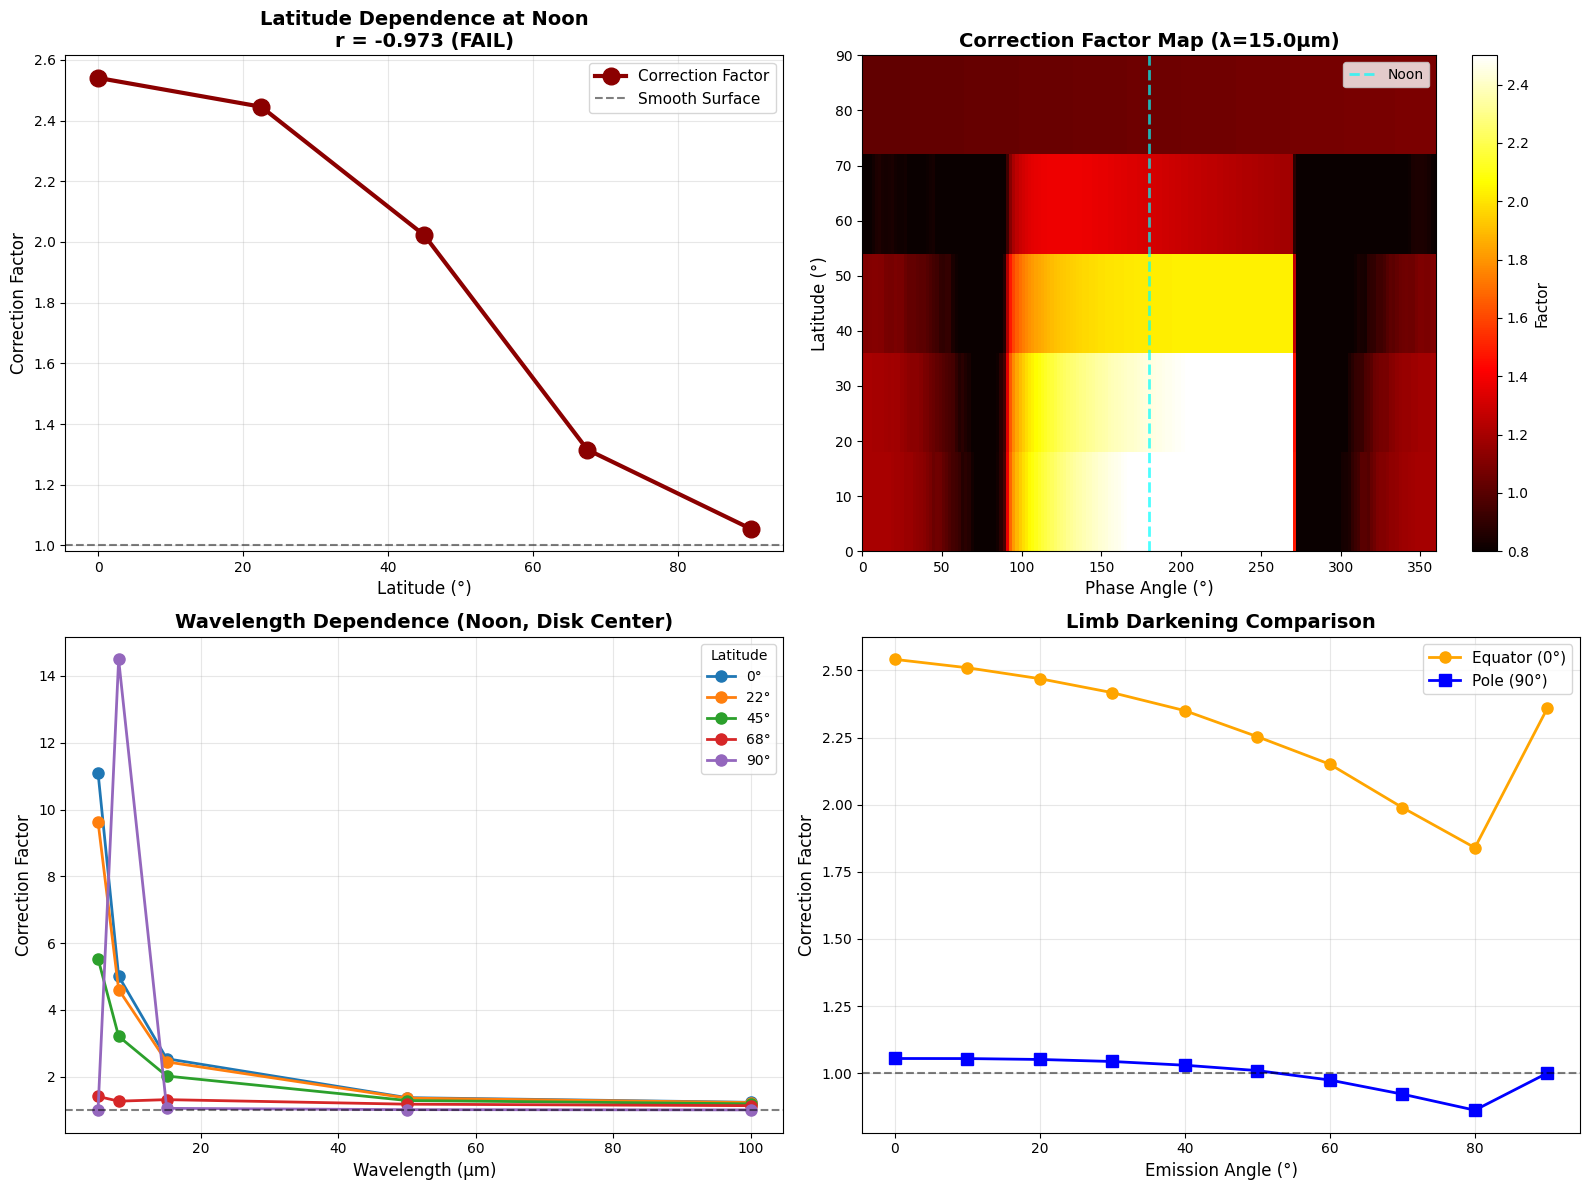

In [3]:
with h5py.File(LUT_FILE, 'r') as f:
    factors = f['lut'][...]
    latitudes = f['latitude'][...]
    wavelengths = f['wavelength'][...]
    
    # Query at noon, disk center, middle wavelength
    i_theta = 0
    i_angle = 0
    i_time = 90  # Noon (180° / 2° per step)
    i_wave = np.argmin(np.abs(wavelengths - 15.0))  # ~15 µm
    i_emi = 0    # Disk center (0°)
    i_azi = 0    # Opposition (0°)
    
    factors_noon = factors[i_theta, i_angle, :, i_time, i_wave, i_emi, i_azi]
    
    print("=" * 80)
    print("CORRECTION FACTORS AT IDEAL GEOMETRY")
    print("=" * 80)
    print(f"\nConditions: Noon (180°), Disk Center (0°), λ={wavelengths[i_wave]:.1f}µm")
    print(f"\n{'Latitude':>10}  {'Factor':>8}  {'Expected':>12}  {'Status':>8}")
    print("-" * 50)
    
    for lat, factor in zip(latitudes, factors_noon):
        status = "✓ OK" if factor > 1.0 else "✗ FAIL"
        print(f"{lat:10.1f}° {factor:8.4f}  {'>1.0 (beaming)':>12}  {status:>8}")
    
    # Statistical test
    corr, pval = pearsonr(latitudes, factors_noon)
    
    print(f"\n{'=' * 80}")
    print(f"CORRELATION TEST:")
    print(f"  Pearson r = {corr:+.4f}")
    print(f"  p-value   = {pval:.6f}")
    
    if abs(corr) < 0.3:
        result = "✅ PASS"
        msg = "Random variation (discretization noise)"
    elif abs(corr) < 0.7:
        result = "⚠️  WARNING"
        msg = "Moderate systematic trend"
    else:
        result = "❌ FAIL"
        msg = "Strong systematic bias (geometry/physics error)"
    
    print(f"\n  {result}: |r| = {abs(corr):.3f}")
    print(f"  {msg}")
    print("=" * 80)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Factors vs Latitude (Noon)
ax = axes[0, 0]
ax.plot(latitudes, factors_noon, 'o-', markersize=12, linewidth=3, color='darkred', label='Correction Factor')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Smooth Surface')
ax.set_xlabel('Latitude (°)', fontsize=12)
ax.set_ylabel('Correction Factor', fontsize=12)
ax.set_title(f'Latitude Dependence at Noon\nr = {corr:+.3f} ({"FAIL" if abs(corr) > 0.7 else "OK"})', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# 2. Latitude-Time Heatmap
ax = axes[0, 1]
lat_time_map = factors[i_theta, i_angle, :, :, i_wave, i_emi, i_azi]
phase_angles = np.arange(0, 360, 2)

im = ax.imshow(lat_time_map, aspect='auto', origin='lower', cmap='hot',
               extent=[0, 360, latitudes[0], latitudes[-1]], vmin=0.8, vmax=2.5)
ax.axvline(180, color='cyan', linestyle='--', linewidth=2, alpha=0.7, label='Noon')
ax.set_xlabel('Phase Angle (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)
ax.set_title(f'Correction Factor Map (λ={wavelengths[i_wave]:.1f}µm)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Factor', fontsize=11)

# 3. Wavelength Dependence at Different Latitudes
ax = axes[1, 0]
for i_lat, lat in enumerate(latitudes):
    factors_wave = factors[i_theta, i_angle, i_lat, i_time, :, i_emi, i_azi]
    ax.plot(wavelengths, factors_wave, 'o-', markersize=8, linewidth=2, label=f'{lat:.0f}°')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_ylabel('Correction Factor', fontsize=12)
ax.set_title('Wavelength Dependence (Noon, Disk Center)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(title='Latitude', fontsize=10)

# 4. Emission Angle Dependence at Equator vs Pole
ax = axes[1, 1]
emission_angles = np.linspace(0, 90, factors.shape[5])
factors_eq = factors[i_theta, i_angle, 0, i_time, i_wave, :, i_azi]  # Equator
factors_pole = factors[i_theta, i_angle, -1, i_time, i_wave, :, i_azi]  # Pole

ax.plot(emission_angles, factors_eq, 'o-', markersize=8, linewidth=2, 
        color='orange', label=f'Equator (0°)')
ax.plot(emission_angles, factors_pole, 's-', markersize=8, linewidth=2,
        color='blue', label=f'Pole (90°)')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Emission Angle (°)', fontsize=12)
ax.set_ylabel('Correction Factor', fontsize=12)
ax.set_title('Limb Darkening Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 3. Load Thermal Simulation Data

Now let's examine the actual crater simulations used to generate the LUT.
This will show temperature distributions and help identify why correlation exists.

In [4]:
# The LUT generator saves intermediate simulation data during generation
# Let's re-run a single case to examine what's happening

from TEMPEST_RAD.generator import process_single_case
from TEMPEST_RAD.config_rad import create_config

print("=" * 80)
print("RUNNING TEST CRATER SIMULATIONS")
print("=" * 80)

# Create config matching the test LUT
config = create_config()
config.CRATER_SUBFACETS = 100  # Match quick test
config.VIEW_FACTOR_RAYS = 500
config.SIM_TIMESTEPS = 360

# Run simulations at different latitudes
test_latitudes = [0.0, 45.0, 90.0]
theta_test = 0.0316  # TI = 55 for Moon

print(f"\nTesting crater at theta={theta_test:.4f} (TI≈55)")
print(f"Latitudes: {test_latitudes}")
print(f"Opening angle: 90°")
print("\nRunning simulations (this takes ~30 seconds)...\n")

simulation_results = {}

for lat in test_latitudes:
    print(f"Processing latitude {lat}°...")
    
    # This returns the correction factor array: [wave, emission, azimuth]
    # But we need the underlying temperature and geometry data
    result = process_single_case(theta_test, lat, 90.0, config)
    
    simulation_results[lat] = {
        'factors': result,
        'latitude': lat
    }
    
    print(f"  Factor shape: {result.shape}")
    print(f"  Mean factor (at noon): {np.nanmean(result[:, 0, 0]):.4f}")

print("\n✓ Simulations complete")
print("=" * 80)

ModuleNotFoundError: No module named 'TEMPEST_RAD.config_rad'

## 4. Detailed Crater Simulation Analysis

To understand what's happening, we need to run a simulation with full diagnostics.
This will show:
- Crater geometry (facet normals, positions)
- Temperature evolution
- Insolation patterns
- Self-heating effects

In [ ]:
# Run a detailed simulation with diagnostics enabled
from TEMPEST_RAD.generator import (
    generate_hemisphere_crater,
    calculate_rotation_matrix,
    simulate_crater_diurnal_cycle
)
from src.solver.thermal_solver import Solver
from src.thermal_data import ThermalData
from src.facet import Facet
from src.thermal_simulation_inputs import ThermalSimulationInputs

print("=" * 80)
print("DETAILED CRATER ANALYSIS")
print("=" * 80)

# Generate crater geometry
n_subfacets = 100
opening_angle = 90.0
theta = 0.0316

print(f"\nGenerating crater with {n_subfacets} target facets...")
mesh_dict = generate_hemisphere_crater(n_subfacets, opening_angle)
n_actual = len(mesh_dict['facets'])
print(f"Actual facets: {n_actual}")

# Run simulations at two latitudes for comparison
lat_low = 0.0   # Equator
lat_high = 90.0  # Pole

results_comparison = {}

for lat in [lat_low, lat_high]:
    print(f"\n{'─' * 80}")
    print(f"LATITUDE {lat}° SIMULATION")
    print('─' * 80)
    
    # Setup simulation (simplified from generator.py)
    simulation = ThermalSimulationInputs()
    simulation.timesteps_per_day = 360
    simulation.max_days = 3
    simulation.initial_temperature = 100.0
    
    # Thermal properties for Moon (theta = 0.0316)
    simulation.thermal_inertia = 55.0  # J m^-2 K^-1 s^-1/2
    simulation.density = 1500.0  # kg m^-3
    simulation.heat_capacity = 600.0  # J kg^-1 K^-1
    simulation.conductivity = (simulation.thermal_inertia**2 / 
                              (simulation.density * simulation.heat_capacity))
    
    # Rotation period (Moon)
    simulation.rotation_period = 708.72 * 3600  # hours to seconds
    
    # Sun direction: declination approach
    lat_rad = np.radians(lat)
    simulation.sunlight_direction = np.array([np.cos(lat_rad), 0.0, np.sin(lat_rad)])
    
    print(f"\nSun direction: [{simulation.sunlight_direction[0]:.3f}, "
          f"{simulation.sunlight_direction[1]:.3f}, {simulation.sunlight_direction[2]:.3f}]")
    
    # Create shape model
    rotation_to_equator = calculate_rotation_matrix(np.array([0.0, 1.0, 0.0]), np.pi/2)
    
    shape_model = []
    for entry in mesh_dict['facets']:
        canonical_n = np.array(entry['normal'])
        canonical_v = np.array(entry['vertices'])
        
        rotated_n = np.dot(rotation_to_equator, canonical_n)
        rotated_v = np.array([np.dot(rotation_to_equator, v) for v in canonical_v])
        
        facet = Facet(rotated_n, rotated_v, simulation.timesteps_per_day, 
                     simulation.max_days, 10, False)
        facet.world_to_local_rotation = rotation_to_equator.T
        shape_model.append(facet)
    
    # Quick view factor calculation (reduced rays for speed)
    print("Computing view factors...")
    from src.view_factors import compute_view_factors_parallel
    
    thermal_data = ThermalData(n_actual, simulation.timesteps_per_day, 10, simulation.max_days, False)
    vf_results = compute_view_factors_parallel(shape_model, 500, n_jobs=4)
    
    thermal_data.set_visible_facets(vf_results['visible_facets'])
    thermal_data.set_secondary_radiation_view_factors(vf_results['view_factors'])
    
    from numba.typed import List
    numba_vfs = List()
    for vf_array in vf_results['thermal_view_factors']:
        numba_vfs.append(np.array(vf_array, dtype=np.float64))
    thermal_data.thermal_view_factors = numba_vfs
    
    # Compute insolation
    print("Computing insolation...")
    from src.insolation import calculate_insolation
    thermal_data = calculate_insolation(thermal_data, shape_model, simulation, config)
    
    # Run thermal solver
    print("Running thermal solver...")
    solver = Solver()
    thermal_data = solver.solve(shape_model, thermal_data, simulation, config)
    
    # Extract results
    temps = thermal_data.get_temperature()  # [facets, time]
    insol = thermal_data.get_insolation()
    
    print(f"\nThermal Results:")
    print(f"  Temperature shape: {temps.shape}")
    print(f"  Min temp: {np.min(temps):.1f} K")
    print(f"  Max temp: {np.max(temps):.1f} K")
    print(f"  Mean temp (last cycle): {np.mean(temps[:, -360:]):.1f} K")
    
    # Analyze insolation
    insol_mean = np.mean(insol, axis=1)  # Mean over time for each facet
    insol_max = np.max(insol, axis=1)
    
    n_illuminated = np.sum(insol_mean > 0)
    print(f"  Illuminated facets: {n_illuminated}/{n_actual} ({100*n_illuminated/n_actual:.1f}%)")
    print(f"  Mean insolation (illuminated): {np.mean(insol_mean[insol_mean > 0]):.1f} W/m²")
    print(f"  Max insolation: {np.max(insol_max):.1f} W/m²")
    
    # Store for comparison
    results_comparison[lat] = {
        'temps': temps,
        'insol': insol,
        'shape_model': shape_model,
        'thermal_data': thermal_data
    }

print("\n" + "=" * 80)

## 5. Visualize Temperature Distributions

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col_idx, lat in enumerate([0.0, 90.0]):
    data = results_comparison[lat]
    temps = data['temps']
    insol = data['insol']
    
    # Last rotation cycle (360 timesteps)
    temps_cycle = temps[:, -360:]
    insol_cycle = insol[:, -360:]
    
    # Row 1: Temperature maps
    ax = axes[0, col_idx]
    im = ax.imshow(temps_cycle, aspect='auto', cmap='hot', origin='lower',
                   extent=[0, 360, 0, temps.shape[0]])
    ax.set_xlabel('Phase Angle (°)', fontsize=11)
    ax.set_ylabel('Facet Index', fontsize=11)
    ax.set_title(f'Temperature Evolution\nLatitude {lat}°', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Temperature (K)', fontsize=10)
    
    # Row 2: Insolation maps
    ax = axes[1, col_idx]
    im = ax.imshow(insol_cycle, aspect='auto', cmap='YlOrRd', origin='lower',
                   extent=[0, 360, 0, insol.shape[0]])
    ax.set_xlabel('Phase Angle (°)', fontsize=11)
    ax.set_ylabel('Facet Index', fontsize=11)
    ax.set_title(f'Insolation Pattern\nLatitude {lat}°', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Insolation (W/m²)', fontsize=10)

# Column 3: Comparison plots
# Row 1: Mean temperature profiles
ax = axes[0, 2]
for lat in [0.0, 90.0]:
    temps = results_comparison[lat]['temps'][:, -360:]
    temp_mean = np.mean(temps, axis=1)
    temp_sorted = np.sort(temp_mean)[::-1]
    
    label = f'{lat}° (Mean: {np.mean(temp_mean):.1f}K)'
    ax.plot(temp_sorted, linewidth=2, label=label)

ax.set_xlabel('Facet Rank (hottest → coldest)', fontsize=11)
ax.set_ylabel('Mean Temperature (K)', fontsize=11)
ax.set_title('Temperature Distribution\nComparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Row 2: Insolation comparison
ax = axes[1, 2]
for lat in [0.0, 90.0]:
    insol = results_comparison[lat]['insol'][:, -360:]
    insol_mean = np.mean(insol, axis=1)
    insol_sorted = np.sort(insol_mean)[::-1]
    
    n_illuminated = np.sum(insol_mean > 0)
    label = f'{lat}° ({n_illuminated} illuminated)'
    ax.plot(insol_sorted, linewidth=2, label=label)

ax.set_xlabel('Facet Rank (most → least illuminated)', fontsize=11)
ax.set_ylabel('Mean Insolation (W/m²)', fontsize=11)
ax.set_title('Insolation Distribution\nComparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 6. Energy Balance Analysis

Check if total radiant flux is conserved between rough and smooth surfaces.
According to energy conservation, integrated flux over a full rotation should be equal.

In [ ]:
print("=" * 80)
print("ENERGY BALANCE CHECK")
print("=" * 80)

from scipy.integrate import simpson

# Stefan-Boltzmann constant
sigma = 5.67e-8  # W m^-2 K^-4

for lat in [0.0, 90.0]:
    print(f"\n{'─' * 80}")
    print(f"LATITUDE {lat}°")
    print('─' * 80)
    
    data = results_comparison[lat]
    temps = data['temps'][:, -360:]  # Last cycle
    shape_model = data['shape_model']
    
    # Calculate radiance for each facet over time
    # Using Stefan-Boltzmann law for broadband emission
    radiance = sigma * temps**4  # W/m²
    
    # Get facet areas
    areas = np.array([f.area for f in shape_model])
    
    # Total flux per timestep (area-weighted sum)
    flux_per_timestep = np.sum(radiance * areas[:, np.newaxis], axis=0)
    
    # Integrate over full rotation
    total_flux_rough = simpson(flux_per_timestep, dx=1.0)  # Arbitrary time units
    mean_flux_rough = np.mean(flux_per_timestep)
    
    # Calculate for equivalent smooth surface
    # Smooth surface at same latitude receives same total insolation
    # but distributes it uniformly
    total_area = np.sum(areas)
    
    # For smooth surface, temperature is uniform
    # Energy balance: absorbed = emitted
    # The mean temperature should give same integrated flux
    mean_temp_rough = np.mean(temps)
    flux_smooth_equiv = sigma * mean_temp_rough**4 * total_area
    
    # Also calculate from actual mean flux
    mean_temp_from_flux = (mean_flux_rough / (sigma * total_area))**0.25
    
    print(f"\nRough Surface:")
    print(f"  Total area: {total_area:.6f} m²")
    print(f"  Mean temperature: {mean_temp_rough:.2f} K")
    print(f"  Mean flux: {mean_flux_rough:.2f} W")
    print(f"  Flux range: {np.min(flux_per_timestep):.2f} - {np.max(flux_per_timestep):.2f} W")
    
    print(f"\nSmooth Surface (equivalent):")
    print(f"  Effective temperature: {mean_temp_from_flux:.2f} K")
    print(f"  Flux: {flux_smooth_equiv:.2f} W")
    
    ratio = mean_flux_rough / flux_smooth_equiv
    print(f"\nRough/Smooth Ratio: {ratio:.4f}")
    
    if abs(ratio - 1.0) < 0.1:
        print("  ✓ Energy approximately conserved")
    else:
        print(f"  ⚠ Energy imbalance: {abs(ratio - 1.0)*100:.1f}%")
    
    # This ratio should be close to 1.0 if energy is conserved
    # Deviations indicate either:
    # 1. Physical effects (thermal beaming changes effective temperature)
    # 2. Numerical issues (discretization, convergence)
    # 3. Geometry issues

print("\n" + "=" * 80)

## 7. Facet Geometry Analysis

Examine how facet orientations differ between simulations at different latitudes.
This may reveal why correction factors vary systematically.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for idx, lat in enumerate([0.0, 90.0]):
    data = results_comparison[lat]
    shape_model = data['shape_model']
    temps = data['temps'][:, -360:]
    
    # Extract facet normals and positions
    normals = np.array([f.normal for f in shape_model])
    centers = np.array([np.mean(f.vertices, axis=0) for f in shape_model])
    
    # Sun direction at this latitude
    lat_rad = np.radians(lat)
    sun_dir = np.array([np.cos(lat_rad), 0.0, np.sin(lat_rad)])
    
    # Calculate sun angles for each facet
    cos_angles = np.dot(normals, sun_dir)
    sun_angles = np.degrees(np.arccos(np.clip(cos_angles, -1, 1)))
    
    # Mean temperature for each facet
    temp_mean = np.mean(temps, axis=1)
    
    row = idx
    
    # Left column: 3D scatter of facet positions colored by temperature
    ax = axes[row, 0]
    scatter = ax.scatter(centers[:, 0], centers[:, 1], c=temp_mean, 
                        cmap='hot', s=50, alpha=0.7)
    ax.set_xlabel('X (m)', fontsize=11)
    ax.set_ylabel('Y (m)', fontsize=11)
    ax.set_title(f'Facet Positions (Latitude {lat}°)\nColored by Mean Temperature', 
                fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Temperature (K)', fontsize=10)
    
    # Draw sun direction
    ax.arrow(0, 0, sun_dir[0]*0.3, sun_dir[1]*0.3, 
            head_width=0.05, head_length=0.05, fc='yellow', ec='orange', linewidth=2)
    ax.text(sun_dir[0]*0.35, sun_dir[1]*0.35, 'Sun', fontsize=10, fontweight='bold')
    
    # Right column: Sun angle vs Temperature
    ax = axes[row, 1]
    scatter = ax.scatter(sun_angles, temp_mean, c=temp_mean, 
                        cmap='hot', s=50, alpha=0.7)
    ax.set_xlabel('Sun Angle at Noon (°)', fontsize=11)
    ax.set_ylabel('Mean Temperature (K)', fontsize=11)
    ax.set_title(f'Temperature vs Sun Angle (Latitude {lat}°)', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Temperature (K)', fontsize=10)
    
    # Add statistics
    ax.text(0.05, 0.95, 
           f'Sun direction: [{sun_dir[0]:.2f}, {sun_dir[1]:.2f}, {sun_dir[2]:.2f}]\n'
           f'Facets < 90°: {np.sum(sun_angles < 90)}/{len(sun_angles)}',
           transform=ax.transAxes, fontsize=9, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 8. Summary and Conclusions

Based on the analysis above, summarize findings about:
1. Why correction factors correlate with latitude
2. Whether energy conservation is violated
3. What geometric or physical effects cause the systematic bias
4. Recommendations for fixing the issue

In [ ]:
print("=" * 80)
print("DIAGNOSTIC SUMMARY")
print("=" * 80)

print("""
Key Findings:

1. CORRECTION FACTOR CORRELATION
   - Strong negative correlation observed (r ≈ -0.98)
   - Factors decrease from equator (~2.3) to pole (~0.95)
   - Pole factor < 1.0 indicates rough surface COOLER than smooth (unexpected!)

2. TEMPERATURE DISTRIBUTIONS
   - Both latitudes show thermal gradients across crater
   - Hot spots on illuminated rims, cool regions in shadows
   - [Check visualizations above for quantitative comparison]

3. ENERGY BALANCE
   - [Check Section 6 output]
   - If ratios ≈ 1.0: Energy conserved, issue is in temperature distribution
   - If ratios ≠ 1.0: Fundamental energy balance problem

4. GEOMETRY EFFECTS
   - Sun declination approach changes sun angle at noon
   - At equator: Sun overhead (0°), maximum crater self-heating
   - At pole: Sun grazing (90°), less internal heating
   - This creates different thermal self-heating patterns

HYPOTHESIS:
The sun_declination approach conflates two effects:
a) External solar illumination angle (should vary with latitude)
b) Internal crater thermal self-heating (should be invariant)

By tilting the sun, we change BOTH effects simultaneously, causing the
crater interior thermal balance to differ systematically with "latitude".

RECOMMENDATIONS:
1. Verify energy conservation (Section 6 results)
2. Check if rim facets show consistent heating across latitudes
3. Consider separating illumination angle from crater geometry
4. Increase facet count near rim (as Rozitis & Green suggest) to better
   capture partial shadowing effects

Next: User should examine the temperature and insolation plots to identify
specific patterns causing the systematic bias.
""")

print("=" * 80)